# Phase III: First ML Proof of Concept (5\%)

### Team Names:
- Gokul Ramanan
- Fanny Cao
- Gensen
- Haojin

In [7]:
!pip install wbdata

In [8]:
# Importing Necessary Libraries
import wbdata as wb
import pandas as pd
import datetime as dt
from sklearn.preprocessing import MinMaxScaler

In [9]:
def clean_data(countries, indicators, year_start, year_end):
  """
    Fetch and preprocess World Bank indicator data for specified countries and years.

    This function retrieves data from the World Bank API for the given indicators and countries,
    converts the date column to integer years, and filters the results to include only data within
    the specified year range.

    Parameters
    ----------
    countries : list of str
        A list of country codes (e.g., ["IN", "US", "CN"]) to retrieve data for.
    indicators : dict
        A dictionary mapping indicator names to World Bank indicator codes.
        Example: {"GDP per capita": "NY.GDP.PCAP.CD"}
    year_start : int
        The starting year of the desired time range.
    year_end : int
        The ending year of the desired time range.

    Returns
    -------
    pandas.DataFrame
        A cleaned DataFrame containing country, date (year), and indicator values
        filtered to the specified range, with a flat index for easier use.
  """

  data = wb.get_dataframe(indicators, country=countries).reset_index()
  data["date"] = data["date"].astype(int)
  data = data[(data["date"] <= year_end) & (data["date"] >= year_start)]
  data = data.dropna(axis=1, thresh= 0.9 * len(data))
  data["country-year"] = data["country"] + " " + data["date"].astype(str)
  data = data.sort_values(by=["country", "date"])

  return data

In [11]:
# List of the top 20 countries ranked by GDP in 2024
# (using ISO-3 country codes as defined by the World Bank API)

countries = ["US", "CN", "DE", "JP", "IN", "GB", "FR", "IT", "CA", "BR", "RU", "MX",
             "AU", "ES", "KR", "ID", "TR", "SA", "NL", "CH"]

# Dictionary of World Bank indicators for GDP growth prediction
# Key = World Bank indicator code
# Value = Custom short name
# Units commented next to each indicator

indicators = {
    # Demographics & Population
    "EN.POP.DNST": "population_density",       # people per sq. km of land area
    "SP.POP.TOTL": "total_population",         # number of people
    "SP.URB.TOTL.IN.ZS": "urban_population_pct", # % of total population living in urban areas
    "SP.DYN.TFRT.IN": "fertility_rate",        # births per woman
    "SP.POP.DPND": "age_dependency_ratio",     # % of working-age population (dependents per 100 working-age people)

    # Health & Capital
    "SP.DYN.LE00.IN": "life_expectancy",       # years
    "SP.DYN.IMRT.IN": "infant_mortality",      # per 1,000 live births
    "SH.XPD.CHEX.PC.CD": "health_exp_pc",      # US$ per capita (current)
    "SH.XPD.CHEX.GD.ZS": "health_exp_gdp_pct", # % of GDP

    # Education System
    "SE.ADT.LITR.ZS": "adult_literacy",        # % of people ages 15+
    "SE.PRM.ENRR": "primary_school_enroll",    # % gross enrollment ratio
    "SE.SEC.ENRR": "secondary_school_enroll",  # % gross enrollment ratio
    "SE.TER.ENRR": "tertiary_school_enroll",   # % gross enrollment ratio
    "SE.XPD.TOTL.GD.ZS": "edu_exp_gdp_pct",    # % of GDP spent on education

    # Economy & Market Growth
    "NY.GDP.PCAP.CD": "gdp_per_capita",        # current US$
    "NE.GDI.TOTL.ZS": "gross_capital_form_pct",# % of GDP (investment)
    "FP.CPI.TOTL.ZG": "inflation_rate",        # annual %, consumer prices
    "SL.UEM.TOTL.ZS": "unemployment_rate",     # % of total labor force
    "NE.TRD.GNFS.ZS": "trade_pct_gdp",         # % of GDP (exports + imports)
    "BX.KLT.DINV.WD.GD.ZS": "fdi_inflows_pct"  # % of GDP (net inflows of FDI)
}

In [12]:
# We want the dataset to include only years between 1980 and 2022
cleaned_data = clean_data(countries, indicators, 1980, 2022)
cleaned_data["gdp_growth"] = cleaned_data.groupby("country")["gdp_per_capita"].pct_change() * 100

# Scale numerical columns that aren't normalized
numeric_cols = ["gdp_per_capita", "total_population"]
scaler = MinMaxScaler()
cleaned_data[numeric_cols] = scaler.fit_transform(cleaned_data[numeric_cols])

# Create numerical country codes for countries
cleaned_data["country_code"] = cleaned_data["country"].astype("category").cat.codes

print(f"The data has {cleaned_data.shape[1]} features and {cleaned_data.shape[0]} observations.")

# Save the cleaned data into a csv for reuseability for ML practice
cleaned_data.to_csv("top20_gdp_indicators_1980_2022.csv", index=False)

The data has 17 features and 860 observations.


/tmp/ipython-input-557482700.py:3: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  cleaned_data["gdp_growth"] = cleaned_data.groupby("country")["gdp_per_capita"].pct_change() * 100


In [13]:
gdp_clean_data = pd.read_csv("top20_gdp_indicators_1980_2022.csv")
gdp_clean_data.head()

,country,date,population_density,total_population,urban_population_pct,fertility_rate,age_dependency_ratio,life_expectancy,infant_mortality,gdp_per_capita,gross_capital_form_pct,inflation_rate,trade_pct_gdp,fdi_inflows_pct,country-year,gdp_growth,country_code
0,Australia,1980,1.912448,0.006090,85.552,1.891,53.522721,74.333659,10.8,0.106303,27.086336,10.135841,32.298275,1.244251,Australia 1980,NaN,0
1,Australia,1981,1.942551,0.006253,85.700,1.935,53.127055,74.663415,10.4,0.123764,28.676818,9.487666,31.603439,1.326516,Australia 1981,16.112228,0
2,Australia,1982,1.976524,0.006437,85.670,1.929,52.700172,74.904878,10.1,0.133589,29.833959,11.351820,30.324690,1.178263,Australia 1982,7.807511,0
3,Australia,1983,2.003758,0.006584,85.641,1.924,52.203948,75.146341,9.8,0.120177,25.301720,10.038911,29.175246,1.687262,Australia 1983,-9.886431,0
4,Australia,1984,2.027959,0.006715,85.611,1.840,51.652832,75.387805,9.6,0.129796,26.629791,3.960396,28.540008,0.221289,Australia 1984,7.868673,0


## Part 1
(3%) The implementation (using NumPy) of your first ML model as a function call to the cleaned data

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import probplot, shapiro
import numpy as np

### Attempt 1 - Linear Regression

In [16]:
def fit_linear_regression(X, y):
    """
    Fit a linear regression model using the normal equation.

    Args:
        X (array): Feature matrix (n_samples, n_features)
        y (array): Target vector (n_samples,)

    Returns:
        tuple: (intercept, coefficients)
    """
    # Add intercept term (column of ones)
    X_with_intercept = np.c_[np.ones(X.shape[0]), X]

    # Normal equation: theta = (X^T X)^-1 X^T y
    theta = np.linalg.inv(X_with_intercept.T @ X_with_intercept) @ X_with_intercept.T @ y

    intercept = theta[0]
    coefficients = theta[1:]

    return intercept, coefficients

In [17]:
def predict(X, intercept, coefficients):
    """
    Make predictions using the fitted model.

    Args:
        X (array): Feature matrix (n_samples, n_features)
        intercept (float): Model intercept
        coefficients (array): Model coefficients

    Returns:
        array: Predicted values
    """
    return X @ coefficients + intercept

In [18]:
def calculate_mse(y_true, y_pred):
    """
    Calculate Mean Squared Error.

    Args:
        y_true (array): True values
        y_pred (array): Predicted values

    Returns:
        float: MSE value
    """
    return np.mean((y_true - y_pred) ** 2)

In [20]:
def calculate_r2(y_true, y_pred):
    """
    Calculate R^2 score.

    Args:
        y_true (array): True values
        y_pred (array): Predicted values

    Returns:
        float: R² value
    """
    mse = calculate_mse(y_true, y_pred)
    return 1 - (mse / np.var(y_true))

In [21]:
def train_test_split_temporal(df, train_end_year=2015):
    """
    Split data temporally - training on early years, testing on later years.

    Args:
        df (DataFrame): Input dataframe
        train_end_year (int): Last year to include in training set

    Returns:
        tuple: (train_mask, test_mask) boolean arrays
    """
    train_mask = df['date'] <= train_end_year
    test_mask = df['date'] > train_end_year

    return train_mask, test_mask

In [31]:
def evaluate_model(X_train, X_test, y_train, y_test, feature_names, title):
    """
    Fit a linear regression model and check assumptions with diagnostic plots.

    Args:
        X_train (array): Training features
        X_test (array): Test features
        y_train (array): Training target
        y_test (array): Test target
        feature_names (list): Names of features for interpretation
        title (str): Title of the model for the graph

    Returns:
        tuple: (intercept, coefficients)
    """
    # Train the model
    intercept, coefficients = fit_linear_regression(X_train, y_train)

    # Predictions
    y_pred_train = predict(X_train, intercept, coefficients)
    y_pred_test = predict(X_test, intercept, coefficients)

    # Model evaluation
    mse_train = calculate_mse(y_train, y_pred_train)
    mse_test = calculate_mse(y_test, y_pred_test)

    r2_train = calculate_r2(y_train, y_pred_train)
    r2_test = calculate_r2(y_test, y_pred_test)

    print(f"Training MSE: {mse_train:.6f}")
    print(f"Testing MSE:  {mse_test:.6f}")
    print(f"Training R²:  {r2_train:.4f}")
    print(f"Testing R²:   {r2_test:.4f}")

    # Print coefficients
    print(f"Intercept: {intercept:.6f}")
    for i, name in enumerate(feature_names):
        print(f"{name}: {coefficients[i]:.2f}")

    # Residuals for test set
    residuals = y_test - y_pred_test

    # Diagnostic Plots
    plt.figure(figsize=(16, 12))

    # 1. Residuals vs Fitted (Linearity/Constant Variance)
    plt.subplot(2, 3, 1)
    plt.scatter(y_pred_test, residuals, alpha=0.5)
    plt.axhline(0, color='red', linestyle='--', linewidth=2)
    plt.title('Residuals vs Fitted Values')
    plt.xlabel('Fitted Values')
    plt.ylabel('Residuals')
    plt.grid(alpha=0.3)

    # 2. Residuals vs Order (Independence check)
    plt.subplot(2, 3, 2)
    plt.scatter(range(len(residuals)), residuals, alpha=0.5)
    plt.axhline(0, color='red', linestyle='--', linewidth=2)
    plt.xlabel("Observation Index")
    plt.ylabel("Residuals")
    plt.title("Residuals vs Order")
    plt.grid(alpha=0.3)

    # 3. Q-Q Plot (Normality)
    plt.subplot(2, 3, 3)
    probplot(residuals, dist="norm", plot=plt)
    plt.title('Normal Q-Q Plot')
    plt.grid(alpha=0.3)

    # 4. Histogram of Residuals (Normality)
    plt.subplot(2, 3, 4)
    plt.hist(residuals, bins=30, density=True, alpha=0.6, color='g', edgecolor='black')
    # Overlay normal distribution
    mu, sigma = residuals.mean(), residuals.std()
    x = np.linspace(residuals.min(), residuals.max(), 100)
    plt.plot(x, 1/(sigma * np.sqrt(2 * np.pi)) * np.exp(-(x - mu)**2 / (2 * sigma**2)),
             'r-', linewidth=2, label='Normal Distribution')
    plt.title('Histogram of Residuals')
    plt.xlabel('Residuals')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(alpha=0.3)

    # 5. Actual vs Predicted
    plt.subplot(2, 3, 5)
    plt.scatter(y_test, y_pred_test, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', linewidth=2, label='Perfect Prediction')
    plt.xlabel('Actual GDP per Capita (scaled)')
    plt.ylabel('Predicted GDP per Capita (scaled)')
    plt.title('Actual vs Predicted Values')
    plt.legend()
    plt.grid(alpha=0.3)

    return intercept, coefficients

In [32]:
def standardize_features(X_train, X_test):
    """
    Standardize features using training set statistics.

    Args:
        X_train (array): Training features
        X_test (array): Test features

    Returns:
        tuple: (X_train_std, X_test_std)
    """
    mean = X_train.mean(axis=0)
    std = X_train.std(axis=0)

    X_train_std = (X_train - mean) / std
    X_test_std = (X_test - mean) / std

    return X_train_std, X_test_std

Training set size: 660 samples (1980-2015)
Testing set size:  139 samples (2016-2022)
Training MSE: 0.010619
Testing MSE:  0.029133
Training R²:  0.6828
Testing R²:   0.4944
Intercept: -10.431275
date: 0.00
population_density: 0.00
total_population: -0.13
life_expectancy: 0.03
infant_mortality: 0.00
gdp_growth: 0.00
inflation_rate: 0.00
age_dependency_ratio: 0.00

Features ranked by importance:
1. life_expectancy          : 0.182865
2. infant_mortality         : 0.072214
3. date                     : 0.041204
4. total_population         : 0.027448
5. population_density       : 0.010792
6. age_dependency_ratio     : 0.009714
7. gdp_growth               : 0.001974
8. inflation_rate           : 0.000121
Standardized model test R^2: 0.4944


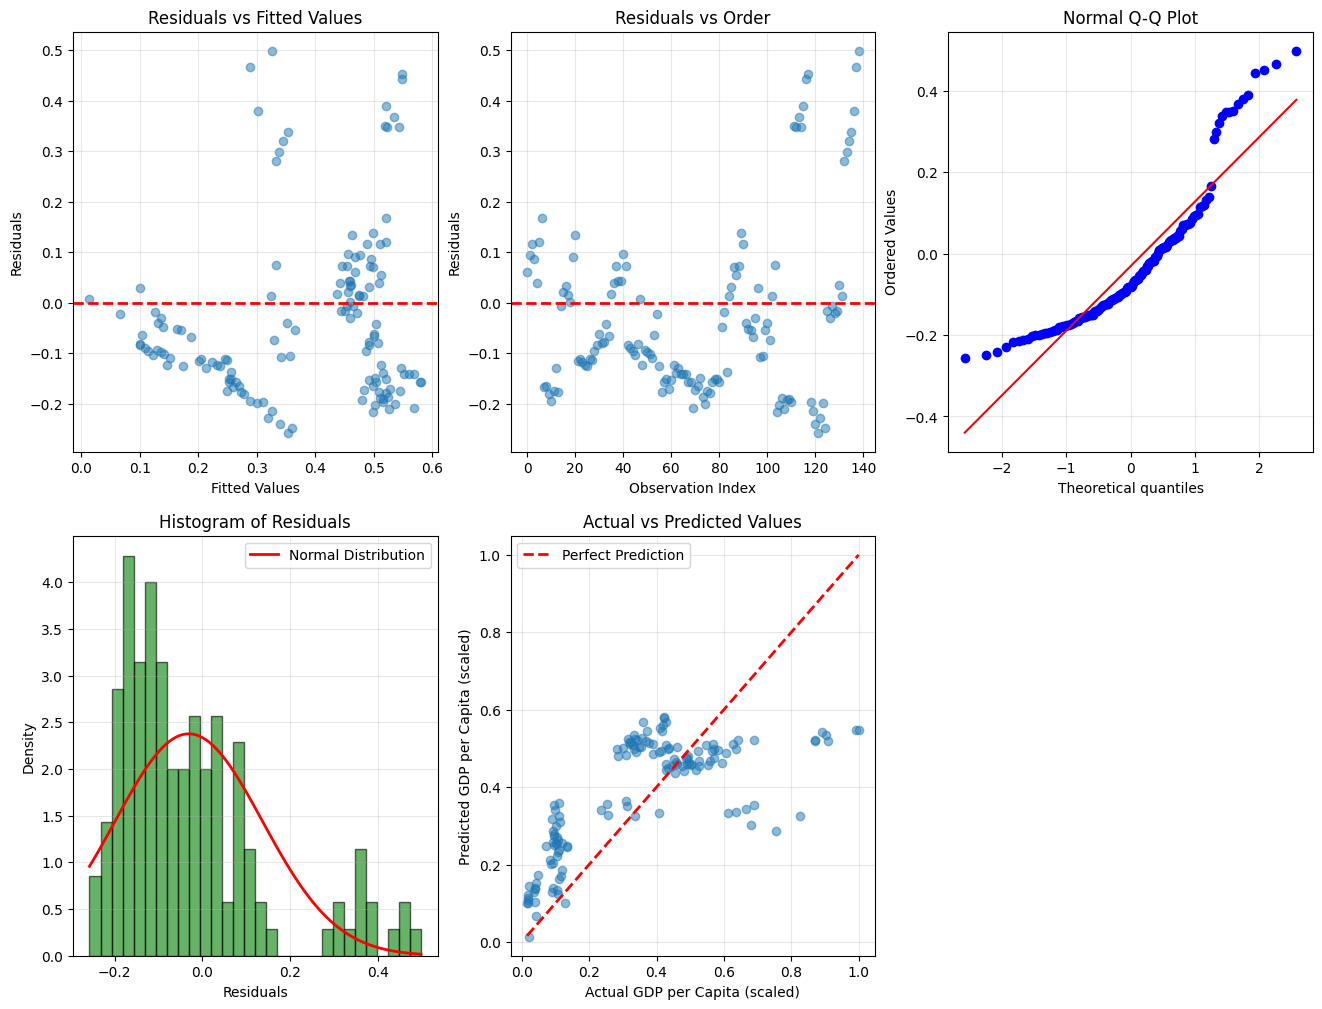

In [33]:
def main():
    # Selected features for prediction
    feature_cols = [
        'date',
        'population_density',
        'total_population',
        'life_expectancy',
        'infant_mortality',
        'gdp_growth',
        'inflation_rate',
        'age_dependency_ratio'
    ]

    target_col = 'gdp_per_capita'

    # Remove rows with missing values in selected features
    df_clean = gdp_clean_data[feature_cols + [target_col]].dropna()

    # Split into features and target
    X = df_clean[feature_cols].values
    y = df_clean[target_col].values

    # Temporal train-test split (1980-2015 train, 2016-2022 test)
    train_mask, test_mask = train_test_split_temporal(df_clean, train_end_year=2015)

    X_train = X[train_mask]
    X_test = X[test_mask]
    y_train = y[train_mask]
    y_test = y[test_mask]

    print(f"Training set size: {X_train.shape[0]} samples (1980-2015)")
    print(f"Testing set size:  {X_test.shape[0]} samples (2016-2022)")

    # Evaluate the full model
    intercept, coefficients = evaluate_model(
        X_train, X_test, y_train, y_test,
        feature_cols,
        "GDP per Capita Prediction Model (Multi-Feature)"
    )

    # Standardize features to compare coefficient magnitudes
    X_train_std, X_test_std = standardize_features(X_train, X_test)

    intercept_std, coefficients_std = fit_linear_regression(X_train_std, y_train)

    # Sort features by absolute coefficient value
    feature_importance = sorted(
        zip(feature_cols, np.abs(coefficients_std)),
        key=lambda x: x[1],
        reverse=True
    )

    print("\nFeatures ranked by importance:")
    for i, (feature, importance) in enumerate(feature_importance, 1):
        print(f"{i}. {feature:25s}: {importance:.6f}")

    # Test the standardized model performance
    y_pred_test_std = predict(X_test_std, intercept_std, coefficients_std)
    r2_test_std = calculate_r2(y_test, y_pred_test_std)
    print(f"Standardized model test R^2: {r2_test_std:.4f}")

if __name__ == '__main__':
    main()

So basically, the linear regression model I made above shows concerning signs of poor fit despite a low MSE. The test R^2 drops significantly by nearly 0.2 compared to training R^2 (0.68 to 0.49), indicating that the model struggles to generalize to unseen data and doesn't account for the variability well. The diagnostic plots (the first four graphs) reveal clear violations of linear regression assumptions: the residuals vs fitted values plot shows distinct clustering patterns rather than random scatter, failing the linearity and constant variance tests. The Q-Q plot displays a pronounced S-curve deviation from the theoretical normal line, indicating the residuals aren't normally distributed. Most tellingly, the actual vs predicted values plot reveals a curved relationship with what appears to be an asymptote around y=0.6, suggesting an exponential or logarithmic relationship would better capture this data than a linear one. These patterns strongly indicate that a non-linear model, particularly one with exponential transformations or polynomial features, would better capture the underlying relationship between our economic indicators and GDP per capita.

### Attempt 2 - Polynomial regression
#### Creating the Design Matrix

Using the `PolynomialFeatures` and `.fit_transform` functions to convert the `hour` ($x$) feature into an array (`X_hour_poly`) that includes columns corresponding to building a quartic model for `tripduration` ($y$) along the lines of: $y = \beta_0 + \beta_1 x + \beta_2 x^2 + \beta_3 x^3 + \beta_4 x^4$.

### Attempt 3 - Polynomial Regression with added interaction terms and dummy variables
#### Creating Fitting Model

$$
y = b_0 + b_1 x_1 + b_2 x_1^2 + b_3 x_1^3 + b_4 x_1^4 + b_5x_1x_3 + b_6x_2x_4 + b_7x_1x_4 + b_8x_2x_3
$$

Where:

- $y$: trip duration
- $x_1$: time of day
- $x_2$: member or casual (1 or 0)
- $x_3$: electric or classic bike (1 or 0)

- Polynomial terms $b_0 + b_1 x_1 + b_2 x_1^2 + b_3 x_1^3 + b_4 x_1^4$
- Interaction terms with dummy variables $b_5x_1x_3 + b_6x_2x_4 + b_7x_1x_4 + b_8x_2x_3$

## Part 2
(2%) A discussion of the preliminary results:
   - This may include checking of assumptions, generated plots/tables, measures of fit, or other attributes of the analysis
   - It does not have to be fully correct, but as a proof of concept must demonstrate that the group is close to completing the analysis